**Бизнес-задача**  

Проанализировать стратегии футбольных клубов из топ 7 лиг + РПЛ на траснферном рынке начиная с 2022 года. Определить схожести и различия в поведении клубов при покупке футболистов.



**Задача машинного обучения:**

Кластеризация

## Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

## Предварительный анализ датасета

In [ ]:
file_path1 = "transfers.csv"

df1 = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "davidcariboo/player-scores",
  file_path1,
)

<ipython-input-2-19f75b3f1bd4>:3: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df1 = kagglehub.load_dataset(


100%|██████████| 6.45M/6.45M [00:00<00:00, 92.3MB/s]


In [ ]:
df1.head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,16136,2026-07-01,26/27,417,123,OGC Nice,Retired,NaN,500000.0,Dante
1,1138758,2026-07-01,26/27,336,631,Sporting CP,Chelsea,52140000.0,45000000.0,Geovany Quenda
2,195778,2026-06-30,25/26,79,27,VfB Stuttgart,Bayern Munich,0.0,12000000.0,Alexander Nübel
3,569033,2026-06-30,25/26,39,27,1.FSV Mainz 05,Bayern Munich,0.0,4000000.0,Armindo Sieb
4,626913,2026-06-30,25/26,398,380,Lazio,Salernitana,0.0,15000000.0,Boulaye Dia


In [ ]:
file_path2 = "clubs.csv"

df2 = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "davidcariboo/player-scores",
  file_path2,
)

<ipython-input-4-065c4a88df46>:3: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df2 = kagglehub.load_dataset(


100%|██████████| 96.7k/96.7k [00:00<00:00, 32.7MB/s]


In [ ]:
df2.head()

,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,105,sv-darmstadt-98,SV Darmstadt 98,L1,NaN,27,25.6,13,48.1,1,Merck-Stadion am Böllenfalltor,17810,+€3.05m,NaN,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/sv-darmstadt-9...
1,11127,ural-ekaterinburg,Ural Yekaterinburg,RU1,NaN,30,26.5,11,36.7,3,Yekaterinburg Arena,23000,+€880k,NaN,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/ural-ekaterinb...
2,114,besiktas-istanbul,Beşiktaş Jimnastik Kulübü,TR1,NaN,30,26.6,15,50.0,8,Beşiktaş Park,42445,€-25.26m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/besiktas-istan...
3,12,as-rom,Associazione Sportiva Roma,IT1,NaN,26,26.3,18,69.2,17,Olimpico di Roma,70634,€-76.90m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/as-rom/startse...
4,148,tottenham-hotspur,Tottenham Hotspur Football Club,GB1,NaN,30,25.5,21,70.0,18,Tottenham Hotspur Stadium,62850,€-120.05m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/tottenham-hots...


In [ ]:
df1 = df1.merge(
    df2[['club_id', 'domestic_competition_id']],
    left_on='to_club_id',
    right_on='club_id',
    how='left'
)

df1.drop(columns='club_id', inplace=True)

In [ ]:
df1.head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id
0,16136,2026-07-01,26/27,417,123,OGC Nice,Retired,NaN,500000.0,Dante,NaN
1,1138758,2026-07-01,26/27,336,631,Sporting CP,Chelsea,52140000.0,45000000.0,Geovany Quenda,GB1
2,195778,2026-06-30,25/26,79,27,VfB Stuttgart,Bayern Munich,0.0,12000000.0,Alexander Nübel,L1
3,569033,2026-06-30,25/26,39,27,1.FSV Mainz 05,Bayern Munich,0.0,4000000.0,Armindo Sieb,L1
4,626913,2026-06-30,25/26,398,380,Lazio,Salernitana,0.0,15000000.0,Boulaye Dia,IT1


In [ ]:
# Размер датасета
df1.shape

(79646, 11)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79646 entries, 0 to 79645
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_id                79646 non-null  int64  
 1   transfer_date            79646 non-null  object 
 2   transfer_season          79646 non-null  object 
 3   from_club_id             79646 non-null  int64  
 4   to_club_id               79646 non-null  int64  
 5   from_club_name           79646 non-null  object 
 6   to_club_name             79646 non-null  object 
 7   transfer_fee             51931 non-null  float64
 8   market_value_in_eur      49330 non-null  float64
 9   player_name              79646 non-null  object 
 10  domestic_competition_id  36393 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.7+ MB


In [ ]:
#Количество пропущенных значений
df1.isnull().sum()

,0
player_id,0
transfer_date,0
transfer_season,0
from_club_id,0
to_club_id,0
from_club_name,0
to_club_name,0
transfer_fee,27715
market_value_in_eur,30316
player_name,0


In [ ]:
# Удаляю строчки с пропущенными значениями в колонках.
df = df1.dropna(subset=['transfer_fee', 'market_value_in_eur', 'domestic_competition_id'])

In [ ]:
# Количество пропущенных значений
df.isnull().sum()

,0
player_id,0
transfer_date,0
transfer_season,0
from_club_id,0
to_club_id,0
from_club_name,0
to_club_name,0
transfer_fee,0
market_value_in_eur,0
player_name,0


In [ ]:
# Фильтрация по дате
df['transfer_date'] = pd.to_datetime(df['transfer_date'], errors='coerce')
df = df[df['transfer_date'].dt.year >= 2022]

<ipython-input-13-41f70eb7a58f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transfer_date'] = pd.to_datetime(df['transfer_date'], errors='coerce')


In [ ]:
# Выбираем лиги, которые нас интересуют
target_leagues = ['GB1', 'ES1', 'FR1', 'IT1', 'NL1', 'PO1', 'L1', 'RU1']

df = df[df['domestic_competition_id'].isin(target_leagues)]

In [ ]:
df

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id
1,1138758,2026-07-01,26/27,336,631,Sporting CP,Chelsea,52140000.0,45000000.0,Geovany Quenda,GB1
2,195778,2026-06-30,25/26,79,27,VfB Stuttgart,Bayern Munich,0.0,12000000.0,Alexander Nübel,L1
3,569033,2026-06-30,25/26,39,27,1.FSV Mainz 05,Bayern Munich,0.0,4000000.0,Armindo Sieb,L1
4,626913,2026-06-30,25/26,398,380,Lazio,Salernitana,0.0,15000000.0,Boulaye Dia,IT1
5,743395,2026-06-30,25/26,9010,15,FCV Dender EH,B. Leverkusen,0.0,1500000.0,Noah Mbamba,L1
...,...,...,...,...,...,...,...,...,...,...,...
25445,599150,2022-01-01,21/22,1124,232,Fakel Voronezh,Spartak Moscow,250000.0,350000.0,Ilya Svinov,RU1
25452,621436,2022-01-01,21/22,3729,232,Arsenal Tula,Spartak Moscow,3000000.0,3500000.0,Daniil Khlusevich,RU1
25505,712857,2022-01-01,21/22,14300,932,Shakhtar U19,Loko Moscow,3000000.0,1000000.0,Mark Mampassi,RU1
25537,789082,2022-01-01,21/22,210,162,Grêmio,Monaco,11000000.0,8500000.0,Vanderson,FR1


In [ ]:
# Проверка результата
df.shape

(8659, 11)

## Разведовательный анализ

In [ ]:
df_clean = df.copy()

# Добавим флаги бесплатных и платных переходов
df_clean['is_paid'] = df_clean['transfer_fee'] > 0
df_clean['is_free'] = df_clean['transfer_fee'] == 0

In [ ]:
# Созздаем таблцу с нужными признаками
club_stats = df_clean.groupby('to_club_name').agg(
    total_fee=('transfer_fee', 'sum'),  # 2. Общая сумма потраченных денег
    num_transfers=('player_id', 'count'),  # 3. Общее количество купленных игроков
    paid_transfers=('is_paid', 'sum'),  # 4. Куплено за деньги
    free_transfers=('is_free', 'sum'),  # 5. Бесплатно подписано
    total_market_value=('market_value_in_eur', 'sum'),  # 7. Суммарная рыночная стоимость
).reset_index()

# 6. Средняя цена игрока за деньги
club_stats['avg_fee_per_paid_player'] = club_stats.apply(
    lambda row: row['total_fee'] / row['paid_transfers'] if row['paid_transfers'] > 0 else 0,
    axis=1
)

# 8. Средняя рыночная цена подписанных игроков
club_stats['avg_market_value_per_player'] = club_stats.apply(
    lambda row: row['total_market_value'] / row['num_transfers'] if row['num_transfers'] > 0 else 0,
    axis=1
)

# 9. Общая разница между рыночной ценой и потраченной суммой
club_stats['value_diff'] = club_stats['total_market_value'] - club_stats['total_fee']

# 10. Средняя разница на одного игрока
club_stats['value_diff_per_player'] = club_stats.apply(
    lambda row: row['value_diff'] / row['num_transfers'] if row['num_transfers'] > 0 else 0,
    axis=1
)

In [ ]:
# Переименуем колонку с названием клуба для удобства
club_stats = club_stats.rename(columns={'to_club_name': 'club'})

In [ ]:
# Итоговая таблица
club_stats = club_stats[[
    'club',
    'total_fee',
    'num_transfers',
    'paid_transfers',
    'free_transfers',
    'avg_fee_per_paid_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]]

In [ ]:
# Округляем все числовые значения до 1 знака после запятой
club_stats = club_stats.round()

In [ ]:
# Просмотр результата
club_stats

,club,total_fee,num_transfers,paid_transfers,free_transfers,avg_fee_per_paid_player,total_market_value,avg_market_value_per_player,value_diff,value_diff_per_player
0,1.FC Köln,10750000.0,28,7,21,1535714.0,60850000.0,2173214.0,50100000.0,1789286.0
1,1.FC Nuremberg,0.0,13,0,13,0.0,15100000.0,1161538.0,15100000.0,1161538.0
2,1.FSV Mainz 05,40600000.0,40,15,25,2706667.0,175350000.0,4383750.0,134750000.0,3368750.0
3,AC Ajaccio,0.0,5,0,5,0.0,3750000.0,750000.0,3750000.0,750000.0
4,AC Milan,300960000.0,74,22,52,13680000.0,730900000.0,9877027.0,429940000.0,5810000.0
...,...,...,...,...,...,...,...,...,...,...
252,West Ham,478560000.0,41,19,22,25187368.0,664800000.0,16214634.0,186240000.0,4542439.0
253,Wigan,35000.0,17,1,16,35000.0,13850000.0,814706.0,13815000.0,812647.0
254,Willem II,1725000.0,18,4,14,431250.0,9125000.0,506944.0,7400000.0,411111.0
255,Wolves,394507000.0,77,26,51,15173346.0,638525000.0,8292532.0,244018000.0,3169065.0


<ipython-input-61-68c79da92cbc>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


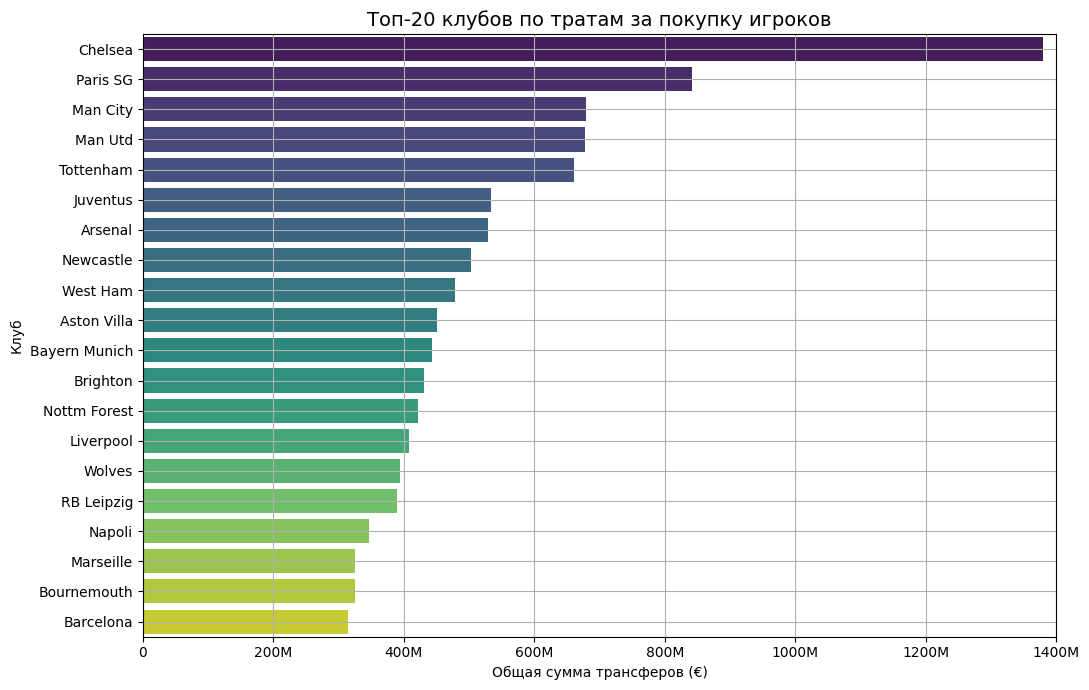

In [ ]:
# Топ-20 клубов по тратам за покупку игроков
top_clubs = club_stats.sort_values(by='total_fee', ascending=False).head(20)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=top_clubs,
    y='club',
    x='total_fee',
    palette='viridis'
)

plt.xlim(0, 1400_000_000)
plt.xticks(
    ticks=[0, 200_000_000, 400_000_000, 600_000_000, 800_000_000, 1_000_000_000, 1200_000_000, 1400_000_000],
    labels=['0', '200M', '400M', '600M', '800M', '1000M', '1200M', '1400M']
)
plt.title('Топ-20 клубов по тратам за покупку игроков', fontsize=14)
plt.xlabel('Общая сумма трансферов (€)')
plt.ylabel('Клуб')
plt.tight_layout()
plt.grid()
plt.show()

<ipython-input-62-4c1f80919f0c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


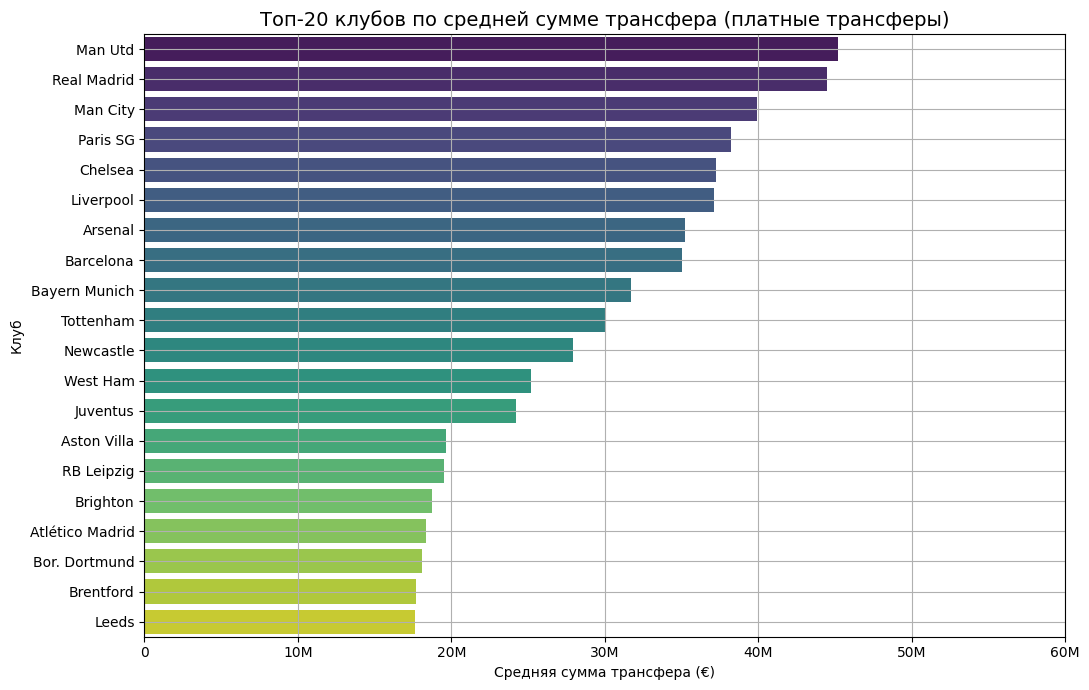

In [ ]:
# Топ-20 клубов по средней сумме трансфера (платные трансферы)
top_clubs = club_stats.sort_values(by='avg_fee_per_paid_player', ascending=False).head(20)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=top_clubs,
    y='club',
    x='avg_fee_per_paid_player',
    palette='viridis'
)

plt.xlim(0, 60_000_000)
plt.xticks(
    ticks=[0, 10_000_000, 20_000_000, 30_000_000, 40_000_000, 50_000_000, 60_000_000],
    labels=['0', '10M', '20M', '30M', '40M', '50M', '60M']
)
plt.title('Топ-20 клубов по средней сумме трансфера (платные трансферы)', fontsize=14)
plt.xlabel('Средняя сумма трансфера (€)')
plt.ylabel('Клуб')
plt.tight_layout()
plt.grid()
plt.show()

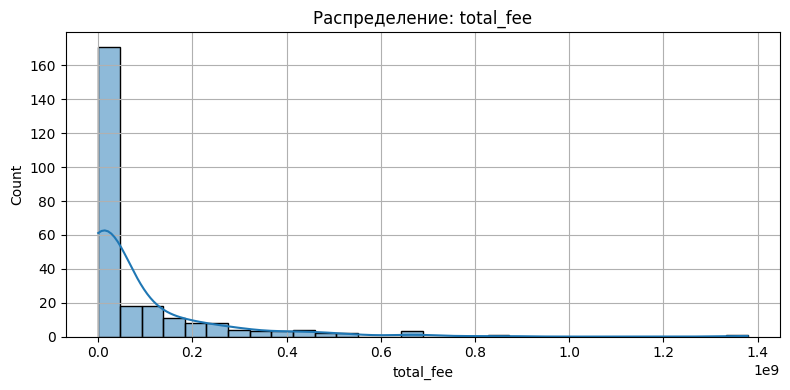

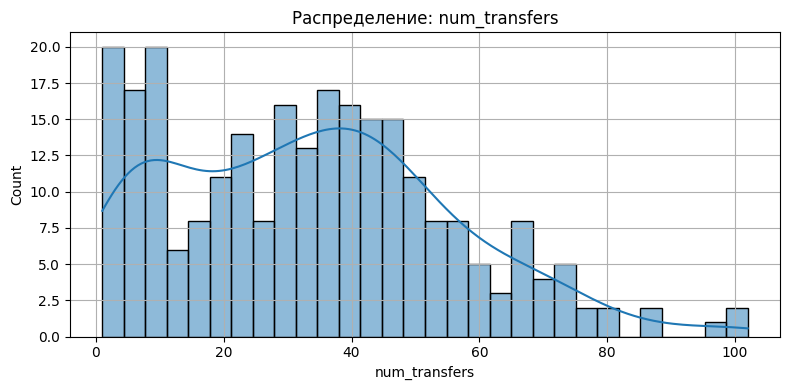

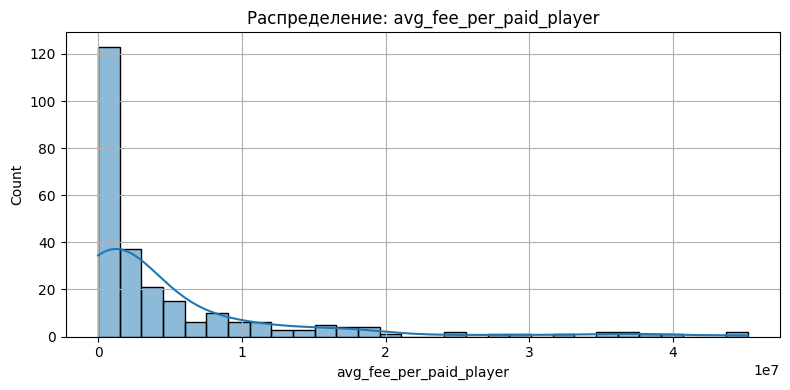

In [ ]:
# Распределение по признакам

cols = ['total_fee', 'num_transfers', 'avg_fee_per_paid_player']

for col in cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(club_stats[col], kde=True, bins=30)
    plt.title(f'Распределение: {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

## Инжирининг признаков

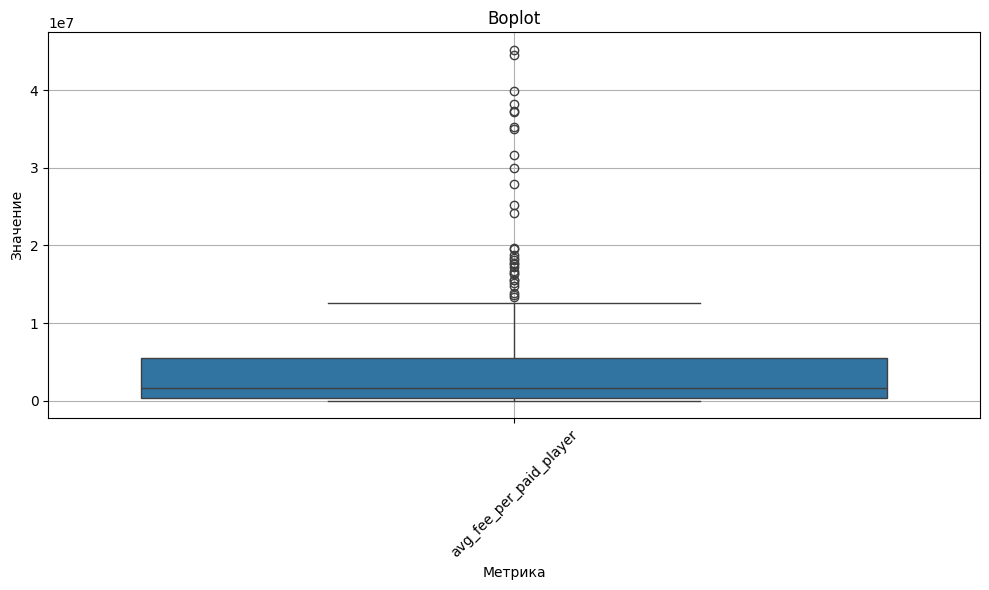

In [ ]:
# Выбираем интересующие числовые признаки
numeric_cols = ['avg_fee_per_paid_player']

# Создаем длинный DataFrame для удобства визуализации
club_stats_melted = club_stats.melt(value_vars=numeric_cols, var_name='Метрика', value_name='Значение')

# Строим boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=club_stats_melted, x='Метрика', y='Значение')
plt.title('Boplot')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
df[df['to_club_name'] == 'Barcelona'].head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id
103,66100,2025-06-30,24/25,12321,131,Girona,Barcelona,0.0,1800000.0,Oriol Romeu,ES1
136,182904,2025-06-30,24/25,13,131,Atlético Madrid,Barcelona,0.0,7500000.0,Clément Lenglet,ES1
642,709957,2025-06-30,24/25,1047,131,Como,Barcelona,0.0,4500000.0,Álex Valle,ES1
1453,709957,2025-01-28,24/25,371,131,Celtic,Barcelona,0.0,3000000.0,Álex Valle,ES1
2866,293385,2024-08-09,24/25,23826,131,RB Leipzig,Barcelona,55000000.0,60000000.0,Dani Olmo,ES1


In [ ]:
df_new = df_clean.copy()
df_new = df_new[df_new['transfer_fee'] > 0]

In [ ]:
df_new[df_new['to_club_name'] == 'Barcelona']

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id,is_paid,is_free
2866,293385,2024-08-09,24/25,23826,131,RB Leipzig,Barcelona,55000000.0,60000000.0,Dani Olmo,ES1,True,False
3217,707572,2024-07-24,24/25,12321,131,Girona,Barcelona,2700000.0,1500000.0,Pau Víctor,ES1,True,False
9796,943837,2024-01-01,23/24,679,131,Athletico-PR,Barcelona,40000000.0,40000000.0,Vitor Roque,ES1,True,False
12204,66100,2023-07-19,23/24,12321,131,Girona,Barcelona,3400000.0,5000000.0,Oriol Romeu,ES1,True,False
19442,411975,2022-07-28,22/23,368,131,Sevilla FC,Barcelona,50000000.0,60000000.0,Jules Koundé,ES1,True,False
19712,38253,2022-07-19,22/23,27,131,Bayern Munich,Barcelona,45000000.0,45000000.0,Robert Lewandowski,ES1,True,False
19961,411295,2022-07-13,22/23,399,131,Leeds,Barcelona,58000000.0,45000000.0,Raphinha,ES1,True,False
21663,720038,2022-07-01,22/23,630,131,Racing,Barcelona,6000000.0,3000000.0,Pablo Torre,ES1,True,False
25396,398184,2022-01-01,21/22,281,131,Man City,Barcelona,55000000.0,45000000.0,Ferran Torres,ES1,True,False


In [ ]:
# Создаем новую таблицу с нужными признаками

club_stats_new = df_new.groupby('to_club_name').agg(
    total_fee=('transfer_fee', 'sum'),  # 2. Общая сумма потраченных денег
    num_transfers=('player_id', 'count'),  # 3. Общее количество купленных игроков
    total_market_value=('market_value_in_eur', 'sum'),  # 5. Суммарная рыночная стоимость
).reset_index()

# 4. Средняя цена игрока за деньги
club_stats_new['avg_fee_per_player'] = club_stats_new.apply(
    lambda row: row['total_fee'] / row['num_transfers'],
    axis=1
)

# 6. Средняя рыночная цена подписанных игроков
club_stats_new['avg_market_value_per_player'] = club_stats_new.apply(
    lambda row: row['total_market_value'] / row['num_transfers'],
    axis=1
)

# 7. Общая разница между рыночной ценой и потраченной суммой
club_stats_new['value_diff'] = club_stats_new['total_market_value'] - club_stats_new['total_fee']


# 8. Средняя разница на одного игрока
club_stats_new['value_diff_per_player'] = club_stats_new.apply(
    lambda row: row['value_diff'] / row['num_transfers'],
    axis=1
)

In [ ]:
club_stats_new = club_stats_new.rename(columns={'to_club_name': 'club'})

In [ ]:
# Итоговая таблица
club_stats_new = club_stats_new[[
    'club',
    'total_fee',
    'num_transfers',
    'avg_fee_per_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]]

In [ ]:
club_stats_new = club_stats_new.round()
club_stats_new

,club,total_fee,num_transfers,avg_fee_per_player,total_market_value,avg_market_value_per_player,value_diff,value_diff_per_player
0,1.FC Köln,10750000.0,7,1535714.0,20250000.0,2892857.0,9500000.0,1357143.0
1,1.FSV Mainz 05,40600000.0,15,2706667.0,82500000.0,5500000.0,41900000.0,2793333.0
2,AC Milan,300960000.0,22,13680000.0,325250000.0,14784091.0,24290000.0,1104091.0
3,AJ Auxerre,8050000.0,8,1006250.0,9550000.0,1193750.0,1500000.0,187500.0
4,AS Roma,143300000.0,13,11023077.0,192500000.0,14807692.0,49200000.0,3784615.0
...,...,...,...,...,...,...,...,...
203,West Ham,478560000.0,19,25187368.0,393800000.0,20726316.0,-84760000.0,-4461053.0
204,Wigan,35000.0,1,35000.0,1800000.0,1800000.0,1765000.0,1765000.0
205,Willem II,1725000.0,4,431250.0,1900000.0,475000.0,175000.0,43750.0
206,Wolves,394507000.0,26,15173346.0,311800000.0,11992308.0,-82707000.0,-3181038.0


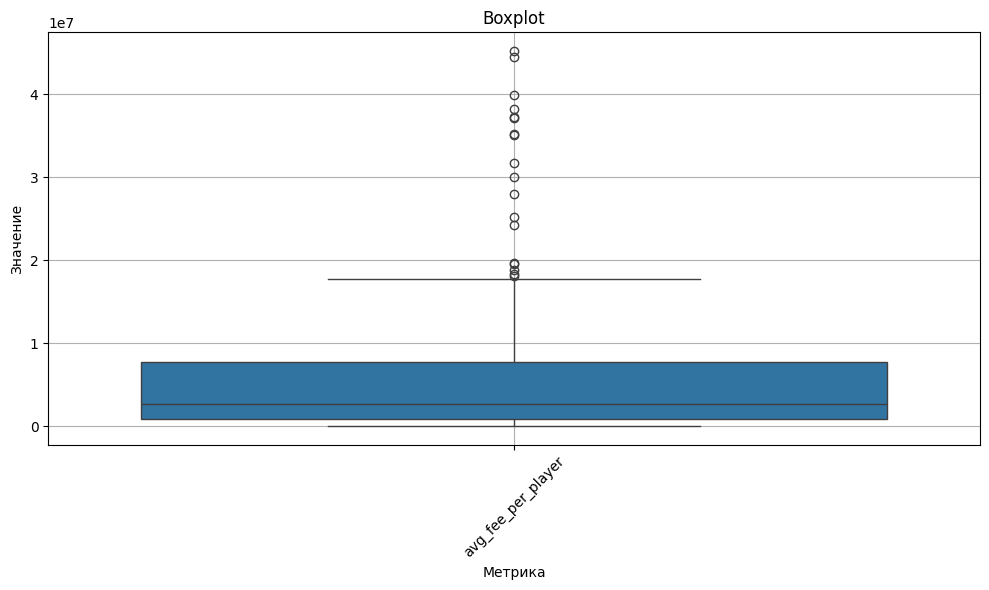

In [ ]:
# Выбираем интересующие числовые признаки
numeric_cols = ['avg_fee_per_player']

# Создаем длинный DataFrame для удобства визуализации
club_stats_new_melted = club_stats_new.melt(value_vars=numeric_cols, var_name='Метрика', value_name='Значение')

# Строим boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=club_stats_new_melted, x='Метрика', y='Значение')
plt.title('Boxplot')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## Построение простой модели

In [ ]:
# Полный набор признаков для кластеризации
features = club_stats_new[[
    'total_fee',
    'num_transfers',
    'avg_fee_per_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]].copy()

In [ ]:
features.round().head()

,total_fee,num_transfers,avg_fee_per_player,total_market_value,avg_market_value_per_player,value_diff,value_diff_per_player
0,10750000.0,7,1535714.0,20250000.0,2892857.0,9500000.0,1357143.0
1,40600000.0,15,2706667.0,82500000.0,5500000.0,41900000.0,2793333.0
2,300960000.0,22,13680000.0,325250000.0,14784091.0,24290000.0,1104091.0
3,8050000.0,8,1006250.0,9550000.0,1193750.0,1500000.0,187500.0
4,143300000.0,13,11023077.0,192500000.0,14807692.0,49200000.0,3784615.0


In [ ]:
# Масштабируем признаки
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

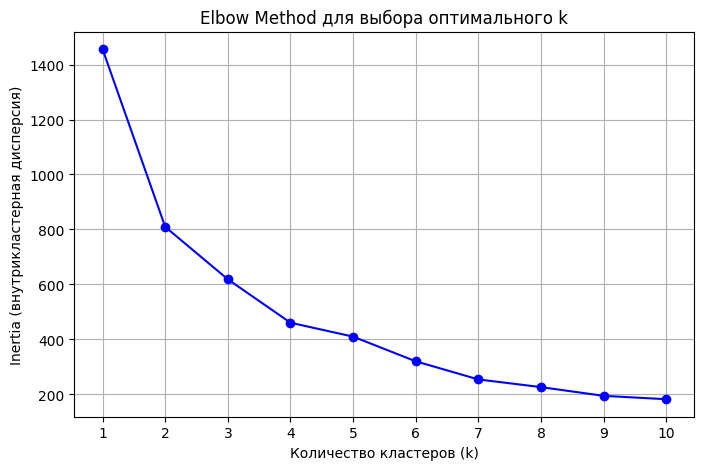

In [ ]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)  # inertia = сумма квадратов расстояний до центров

# График
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, 'bo-')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia (внутрикластерная дисперсия)')
plt.title('Elbow Method для выбора оптимального k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
# Задаём количество кластеров (например, 4)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Обучаем модель на признаках
kmeans.fit(features_scaled)

# Получаем метки кластеров
features['cluster'] = kmeans.labels_

In [ ]:
# Средние значения признаков внутри каждого кластера
cluster_summary = features.groupby('cluster').mean(numeric_only=True)
cluster_summary.round()

,total_fee,num_transfers,avg_fee_per_player,total_market_value,avg_market_value_per_player,value_diff,value_diff_per_player
cluster,,,,,,,
0,17111219.0,8.0,1944300.0,20866423.0,2321400.0,3755204.0,377099.0
1,853043333.0,23.0,36789669.0,581800000.0,25941201.0,-271243333.0,-10848468.0
2,482436154.0,17.0,30665527.0,470826923.0,30096155.0,-11609231.0,-569373.0
3,186142455.0,20.0,9716506.0,172539545.0,8911346.0,-13602909.0,-805161.0


<ipython-input-82-3b195e10ab60>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  labeled_samples = features.groupby('cluster').apply(


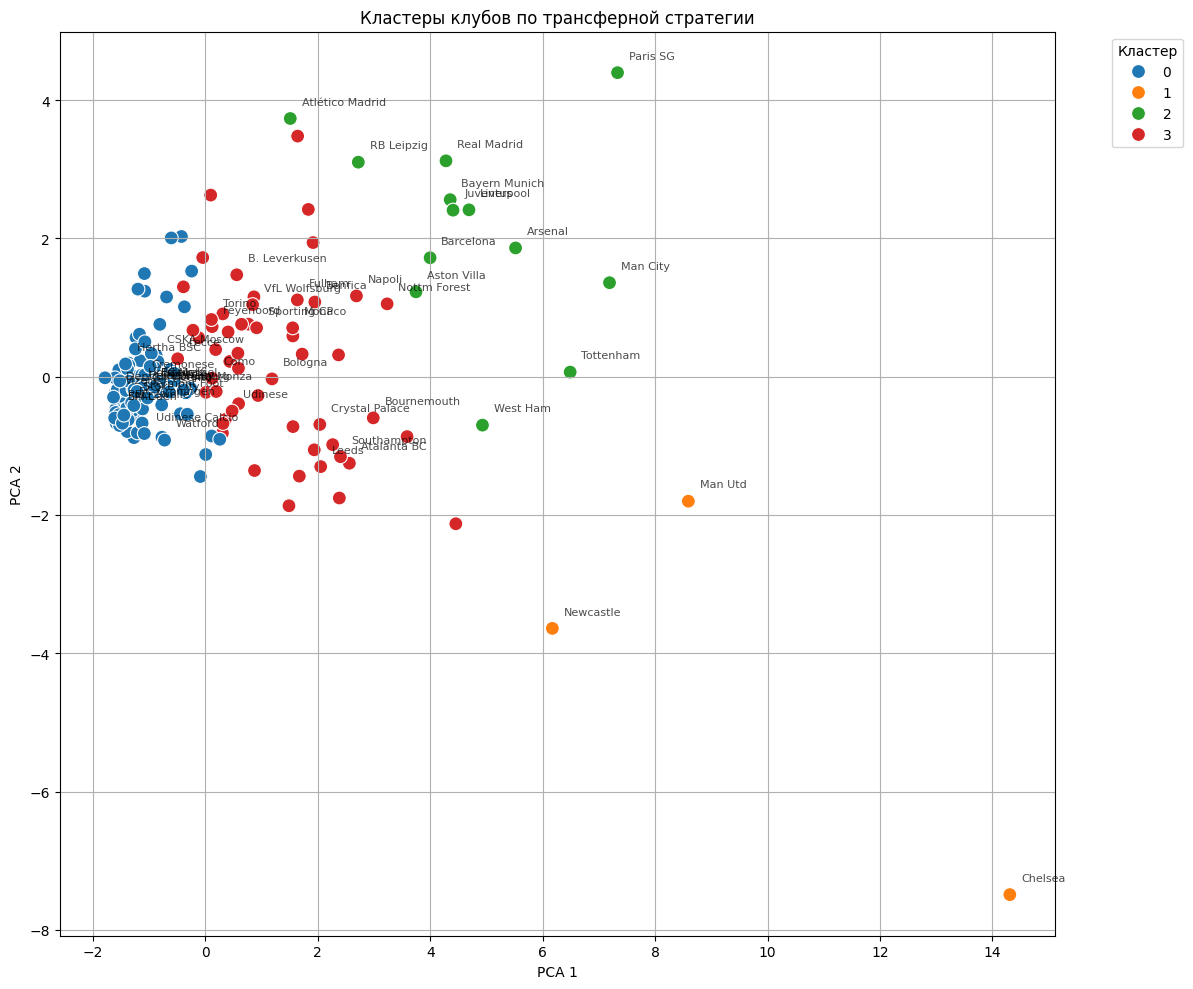

In [ ]:
# PCA для уменьшения размерности до 2 компонент
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

# Добавим координаты PCA и кластеры в таблицу
features['pca_1'] = pca_result[:, 0]
features['pca_2'] = pca_result[:, 1]

# Если у тебя есть названия клубов в club_stats_new, подсоедини их:
features['club'] = club_stats_new['club'].values

# Выбираем по 20 случайных клубов из каждого кластера для подписи
labeled_samples = features.groupby('cluster').apply(
    lambda x: x.sample(min(20, len(x)), random_state=42)
).reset_index(drop=True)

# Визуализация
plt.figure(figsize=(12, 10))
sns.scatterplot(data=features, x='pca_1', y='pca_2', hue='cluster', palette='tab10', s=100)

# Подписи
for _, row in labeled_samples.iterrows():
    plt.text(
        row['pca_1'] + 0.2,
        row['pca_2'] + 0.2,
        row['club'],
        fontsize=8,
        alpha=0.7
    )

plt.title('Кластеры клубов по трансферной стратегии')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()

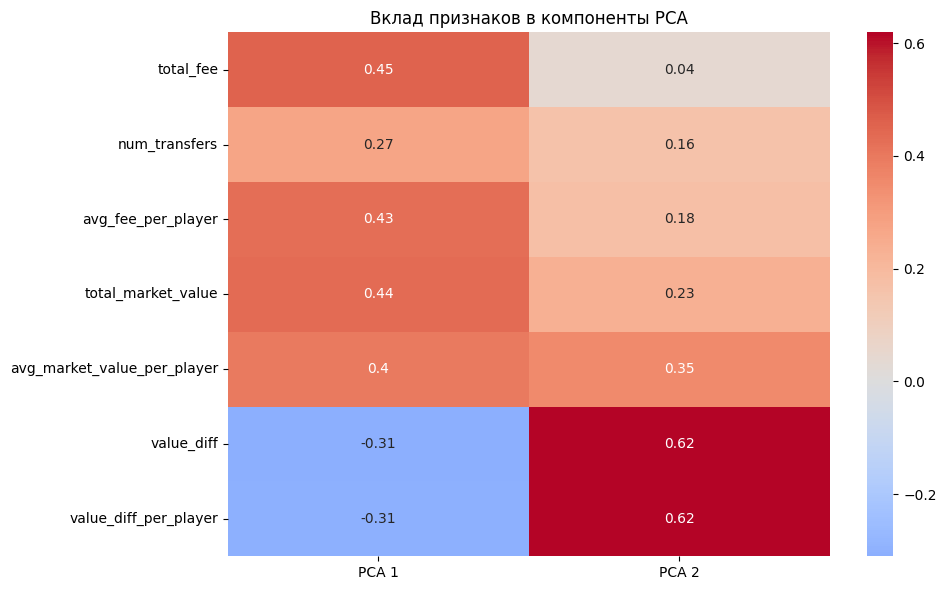

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

pca_features = [
    'total_fee',
    'num_transfers',
    'avg_fee_per_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]

pca_components = pd.DataFrame(
    pca.components_,
    columns=pca_features,
    index=['PCA 1', 'PCA 2']
)

plt.figure(figsize=(10, 6))
sns.heatmap(pca_components.T, annot=True, cmap='coolwarm', center=0)
plt.title('Вклад признаков в компоненты PCA')
plt.tight_layout()
plt.show()

In [ ]:
# Группировка по кластеру и вывод списка клубов
for cluster_id, group in features.groupby('cluster'):
    print(f"\nКластер {cluster_id}:")
    print(group['club'].tolist())


Кластер 0:
['1.FC Köln', '1.FSV Mainz 05', 'AJ Auxerre', 'AZ Alkmaar', 'Akhmat Grozny', 'Akron Togliatti', 'Alavés', 'Amiens SC', 'Angers SCO', 'Arouca', 'Arsenal Tula', 'Athletic', 'Baltika', 'Benevento', 'Boavista', "Bor. M'gladbach", 'Brescia', 'CA Osasuna', 'CD Leganés', 'CSKA Moscow', 'Cagliari', 'Cagliari Calcio', 'Cardiff', 'Casa Pia', 'Celta de Vigo', 'Chaves', 'Clermont Foot', 'Cremonese', 'Crotone', 'Cádiz CF', 'Darmstadt 98', 'Dep. La Coruña', 'Dinamo Makhach.', 'Dynamo Moscow', 'Elche CF', 'Espanyol', 'Estoril Praia', 'Estrela Amadora', 'Excelsior', 'F. Düsseldorf', 'FC Augsburg', 'FC Empoli', 'FC Groningen', 'FC Ingolstadt', 'FC Lorient', 'FC Metz', 'FC Nantes', 'FC Schalke 04', 'FC St. Pauli', 'FC Utrecht', 'Fakel Voronezh', 'Famalicão', 'Fortuna Sittard', 'Frosinone', 'G. Bordeaux', 'Getafe', 'Gil Vicente', 'Girona', 'Go Ahead Eagles', 'Granada CF', 'Greuther Fürth', 'Hamburger SV', 'Hannover 96', 'Heerenveen', 'Heidenheim', 'Heracles Almelo', 'Hertha BSC', 'Holstein Ki

**Характеристика кластеров:**

**Кластер 0:** Малобюджетные клубы, которые преобретают малое количество игроков (в среднем 8) за маленькие деньги (около 1,9 млн за игрока). Эти клубы работают в рамках ограниченого бюджета. Из плюсов: положительная разница между текущей рыночной ценой игрока и деньгами, потраченными за его покупку (в среднем 380 тысяч за игрока). Спортивные цели этих клубов, как правило, выход в высший дивизион, сохранение прописки в высшим дивизионе, попадание в еврокубки.

**Кластер 1:** Клубы, которые покупают игроков много (в среднем 23) и за дорого (в среднем 37 млн за одного игрока). Клубы с богатыми владельцами и большой фанатской аудитории. Эти клубы явно переплачивают, тк игроки, за которых они отдают колоссальные деньги падают или недостаточно растут в цене (в среднем переплачивают 11 млн за одного игрока, исходя из его текущей трансферной цены). Также эти клубы практически безуспешны в последние 3-4 года. Мы можем сделать вывод, что необдуманная переплата ни к чему хорошему не приводит.

**Кластер 2:** Топ клубы, имеющую сбалансированную стратегию на трансферном рынке. Да, могут переплатить за игроков, которые им действительно нужны, но при этом баланс между текущей рыночной ценой и деньгами, потраченными в среднем за игрока стремится к равному значению. Как правило, эти клубы постоянно играют в еврокубках и борятся за все внутренние и внешние турниры. И, как правило, они эти турниры и выигрывают. А также они обладают огромной фанатской аудиторией. В общем, крутые клубы и тоттенхем.

**Кластер 3:** Клубы с ограниченным бюджетом, которые успешно борятся с клубами кластеров 1, 2 за трофеи и места в престижных еврокубковых туринирах. В среднем покупают много игроков (около 20), но за невысокую стоимость (около 10 млн за игрока). Игроки не сильно теряют в цене, баланс между рыночной стоимости и потраченных денег близок к 0. Некоторые из этих клубов лучшие в своих внутренних туринрах (Италия, Россия, Нидерланда, Россия). Но для Англии, Испании, Германии этого недостаточно.



## Отбор признаков

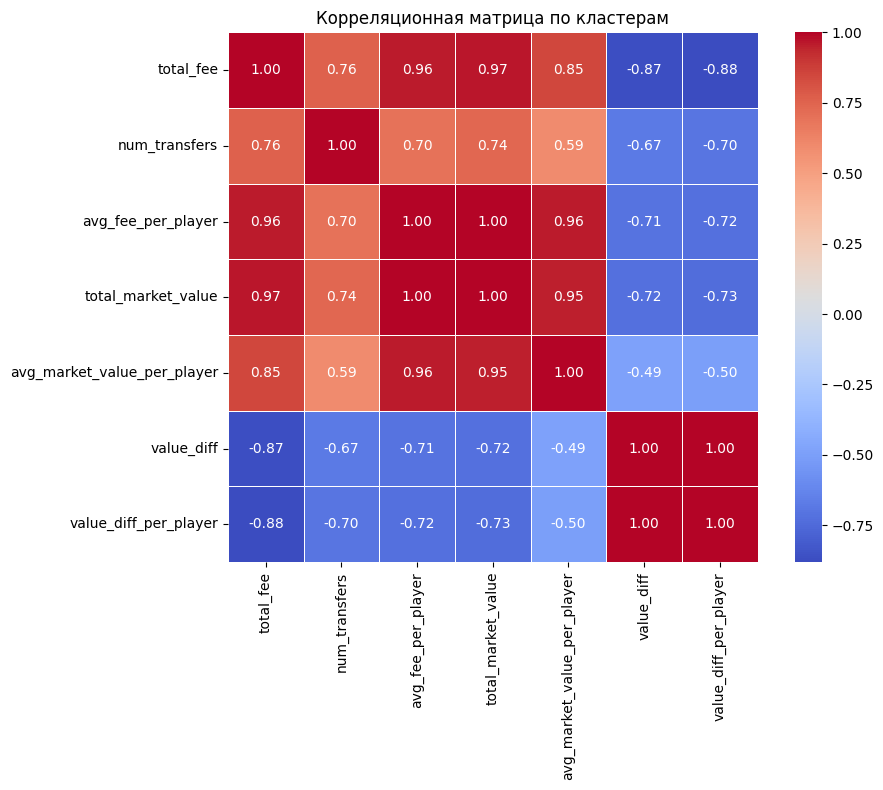

In [ ]:
# Группировка по кластерам и усреднение признаков
cluster_summary = features.groupby('cluster')[[
    'total_fee',
    'num_transfers',
    'avg_fee_per_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]].mean()

# Построение корреляционной матрицы
corr = cluster_summary.corr()

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title('Корреляционная матрица по кластерам')
plt.tight_layout()
plt.show()

In [ ]:
# Суммарный абсолютный вклад каждого признака во все компоненты
pca = PCA()
pca.fit(features_scaled)
explained_variance = pca.explained_variance_ratio_
components = pd.DataFrame(pca.components_, columns=cluster_summary.columns)
feature_importance = components.abs().sum(axis=0)

# Сортируем признаки по важности
top_features = feature_importance.sort_values(ascending=False).head(5)
print("Топ признаков по важности:")
print(top_features)

# Оставляем только топ-признаки
selected_features = features[top_features.index].copy()

Топ признаков по важности:
avg_market_value_per_player    2.472085
avg_fee_per_player             2.358148
total_market_value             2.319715
value_diff_per_player          2.172142
value_diff                     2.154762
dtype: float64


## Построение других моделей (в том числе  Ансамблевые модели)

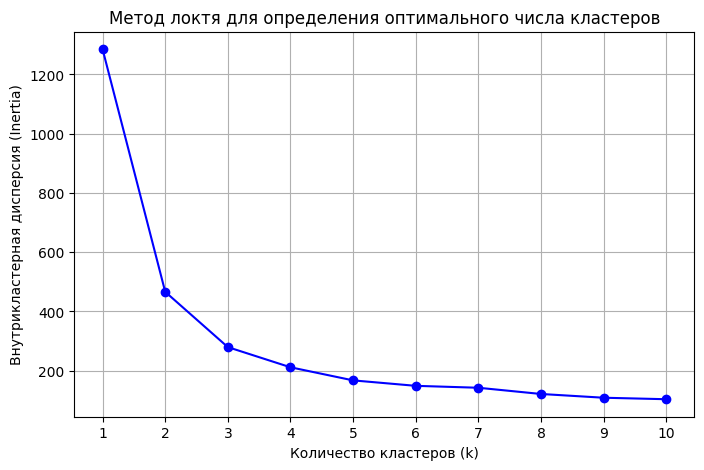

In [ ]:
# Строим метод локтя уже по отобранным признакам

# Масштабирование признаков
selected_features = [
    'avg_market_value_per_player',
    'avg_fee_per_paid_player',
    'total_market_value',
    'value_diff_per_player',
    'value_diff'
]

X = club_stats[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Метод локтя
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Внутрикластерная дисперсия (Inertia)')
plt.title('Метод локтя для определения оптимального числа кластеров')
plt.xticks(k_range)
plt.grid(True)
plt.show()

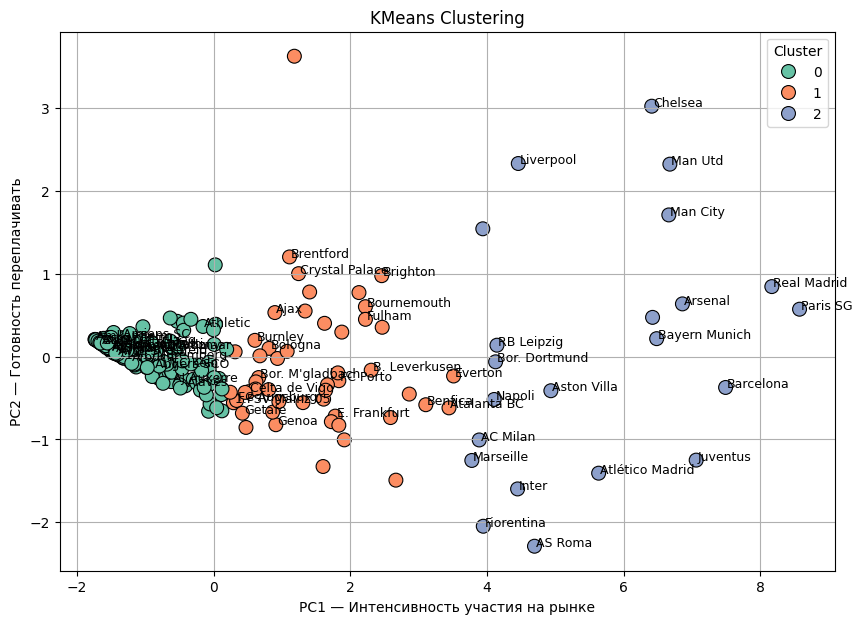

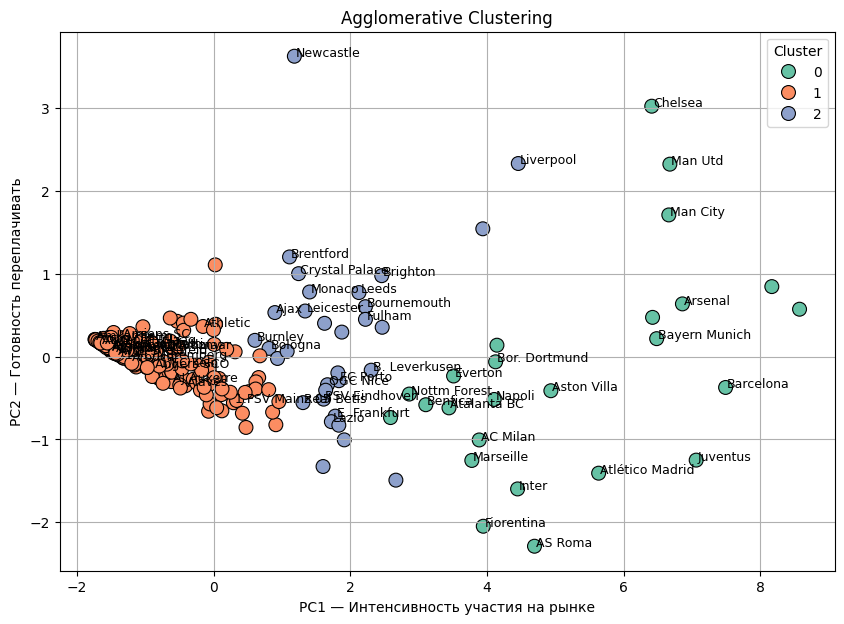

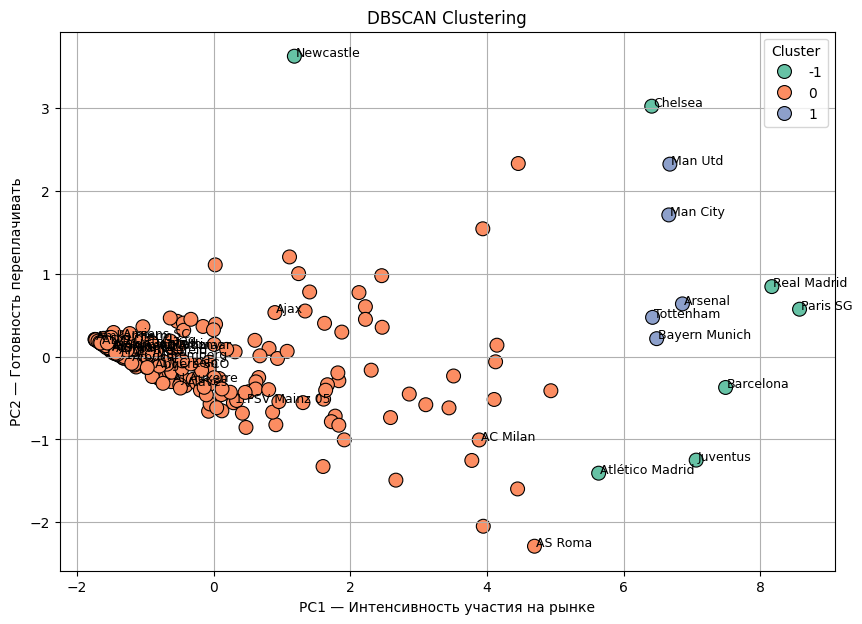

In [ ]:
selected_features = [
    'avg_market_value_per_player',
    'avg_fee_per_paid_player',
    'total_market_value',
    'value_diff_per_player',
    'value_diff'
]

X = club_stats[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
club_stats['PC1'] = X_pca[:, 0]
club_stats['PC2'] = X_pca[:, 1]

kmeans = KMeans(n_clusters=3, random_state=42)
club_stats['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=3)
club_stats['cluster_agglo'] = agglo.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=3)
club_stats['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

def plot_clusters_with_labels(data, cluster_col, title):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=data, x='PC1', y='PC2', hue=cluster_col, palette='Set2', s=100, edgecolor='black')
    plt.xlabel('PC1 — Интенсивность участия на рынке')
    plt.ylabel('PC2 — Готовность переплачивать')
    plt.title(title)

    for cluster in data[cluster_col].unique():
        sub = data[data[cluster_col] == cluster].head(20)
        for _, row in sub.iterrows():
            plt.text(row['PC1'] + 0.02, row['PC2'], row['club'], fontsize=9)

    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

# 5. Построение графиков
plot_clusters_with_labels(club_stats, 'cluster_kmeans', 'KMeans Clustering')
plot_clusters_with_labels(club_stats, 'cluster_agglo', 'Agglomerative Clustering')
plot_clusters_with_labels(club_stats, 'cluster_dbscan', 'DBSCAN Clustering')

**KMeans**:
Алгоритм делит все клубы на заданное число групп (кластеров), находя центры этих групп и распределяя клубы по принципу "кто ближе к какому центру". Повторяет процесс, пока не найдёт наилучшее разделение.


**Agglomerative Clustering (иерархическая)**:
Начинает с того, что каждый клуб — отдельная группа, а затем постепенно "склеивает" их в более крупные кластеры, пока не получится нужное количество.


**DBSCAN**:
находит **естественные скопления клубов** и игнорирует тех, кто сильно отличается от всех (например, супербогатые топ-клубы).

In [ ]:
# Вывод весов признаков в каждой главной компоненте
pca_components = pd.DataFrame(
    pca.components_,
    columns=selected_features,
    index=['PC1', 'PC2']
)

# Показать
print(pca_components.T.sort_values(by='PC1', ascending=False))

                                  PC1       PC2
avg_market_value_per_player  0.464274  0.264622
total_market_value           0.454683  0.112897
value_diff                   0.439254 -0.569355
avg_fee_per_paid_player      0.438976  0.623784
value_diff_per_player        0.438257 -0.451617


## Подбор гиперпараметров к лучшей модели

In [ ]:
score_kmeans = silhouette_score(X_scaled, club_stats['cluster_kmeans'])
score_agglo = silhouette_score(X_scaled, club_stats['cluster_agglo'])

print(f'Silhouette (KMeans): {score_kmeans:.3f}')
print(f'Silhouette (Agglomerative): {score_agglo:.3f}')
print(f'Silhouette (DBSCAN): {score_agglo:.3f}')

Silhouette (KMeans): 0.599
Silhouette (Agglomerative): 0.584
Silhouette (DBSCAN): 0.584


k = 2, silhouette score = 0.6851
k = 3, silhouette score = 0.5868
k = 4, silhouette score = 0.5641
k = 5, silhouette score = 0.4950
k = 6, silhouette score = 0.4749
k = 7, silhouette score = 0.4897
k = 8, silhouette score = 0.4457
k = 9, silhouette score = 0.4480
k = 10, silhouette score = 0.4501


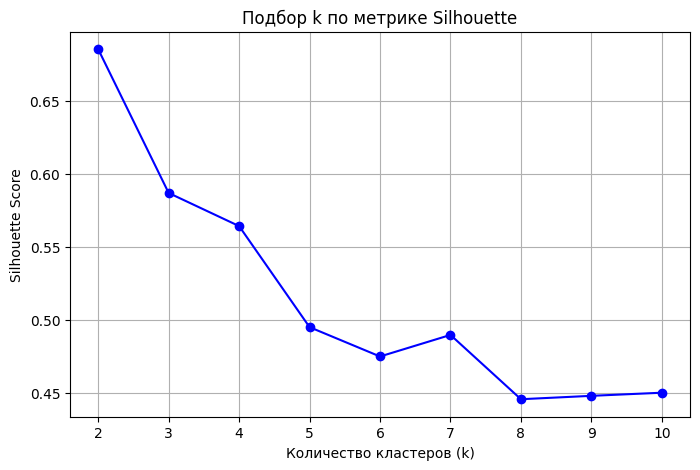


✅ Лучшее значение k: 2 (максимальный silhouette score = 0.6851)


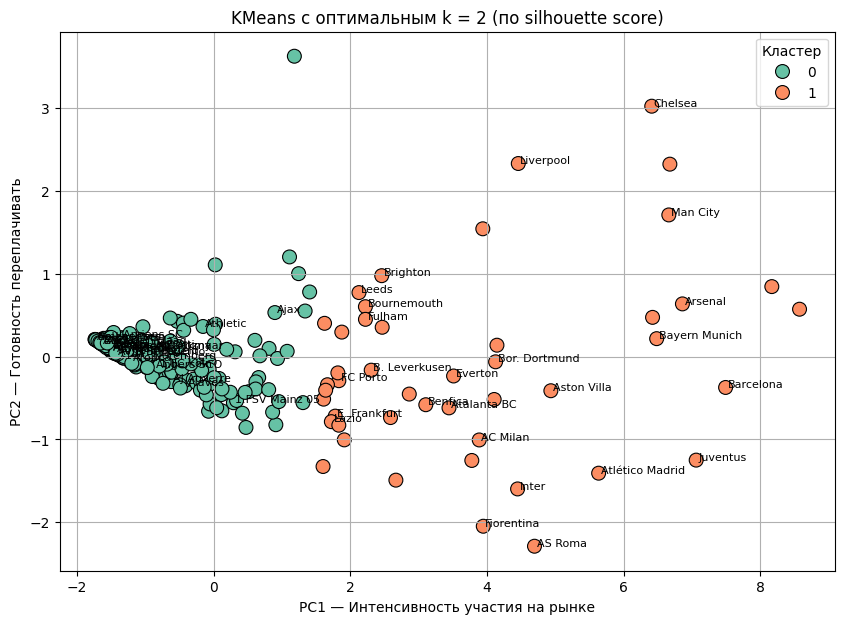

In [ ]:
# Silhouette Score (коэффициент силуэта) показывает, насколько близко каждый объект к своему кластеру и насколько далеко от других кластеров.

# 1. Перебор разных значений k
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k}, silhouette score = {score:.4f}")

# 2. Визуализация результатов
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel("Количество кластеров (k)")
plt.ylabel("Silhouette Score")
plt.title("Подбор k по метрике Silhouette")
plt.grid(True)
plt.show()

# 3. Выбор наилучшего k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✅ Лучшее значение k: {best_k} (максимальный silhouette score = {max(silhouette_scores):.4f})")

# 4. Финальная модель
final_kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=42)
club_stats['best_kmeans_cluster'] = final_kmeans.fit_predict(X_scaled)

# 5. Визуализация с подписями
plt.figure(figsize=(10, 7))
sns.scatterplot(data=club_stats, x='PC1', y='PC2', hue='best_kmeans_cluster', palette='Set2', s=100, edgecolor='black')
plt.xlabel('PC1 — Интенсивность участия на рынке')
plt.ylabel('PC2 — Готовность переплачивать')
plt.title(f"KMeans с оптимальным k = {best_k} (по silhouette score)")
plt.grid(True)

for cluster in club_stats['best_kmeans_cluster'].unique():
    subset = club_stats[club_stats['best_kmeans_cluster'] == cluster].head(25)
    for _, row in subset.iterrows():
        plt.text(row['PC1'] + 0.03, row['PC2'], row['club'], fontsize=8)

plt.legend(title="Кластер")
plt.show()

**Кластер 1: Гранд-Инвесторы**

Типичные представители:
Chelsea, Manchester City, Manchester United, Arsenal, Bayern Munich, Barcelona, Juventus, Atlético Madrid, PSG, Inter, Roma

Характеристика:

Клубы с высокой покупательной способностью.
Делают дорогие трансферы, часто за пределами рыночной стоимости.
Могут позволить себе переплаты ради усиления состава.
Их стратегия направлена на немедленный спортивный результат и усиление бренда.
Это топ-клубы, играющие на рынке без ограничений: приобретают звёзд, платят премиум и часто ведут себя агрессивно.

**Кластер 0: Экономные клубы**

Типичные представители:
Ajax, PSV, Mainz, Bologna, Brentford, Crystal Palace, Brighton, Sporting, Anderlecht, Toulouse

Характеристика:

Работают в условиях ограниченного бюджета.
Делают более взвешенные и эффективные трансферы.
Часто ориентируются на развитие молодых игроков и перепродажу с прибылью.
Показывают высокую среднюю эффективность сделок (покупают дешевле рыночной стоимости).
Это клубы, чья трансферная стратегия основана на скаутинге, аналитике и устойчивом развитии.

## Итог и сохрание модели

**Проанализровав датасет и построив модели машинного обучения, мы пришли к тому, что наилучшая модель, это Kmeans. Мы смогли сгруппировать футбольные клубы, оперевшись на наиболее важные признаки. У нас вышло 2 группы футбольных клубов с кардинально разными стратегиями на трансферном рынке.**

In [ ]:
# Сохранение вручную подобранной модели KMeans
joblib.dump(final_kmeans, 'best_kmeans_model.pkl')

['best_kmeans_model.pkl']